Processing M20 D14...


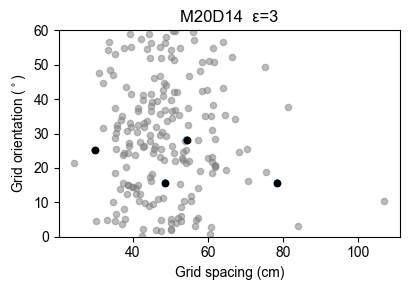

Processing M20 D15...


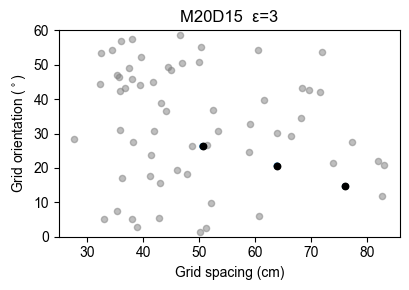

Processing M20 D16...


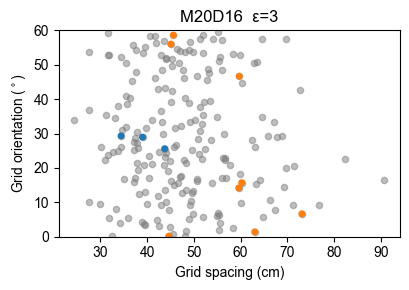

Processing M20 D17...


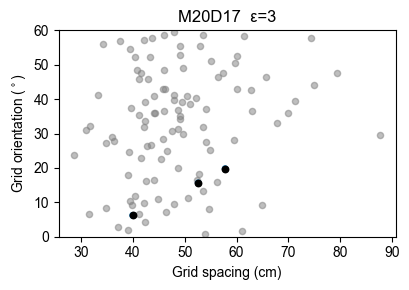

Processing M20 D18...


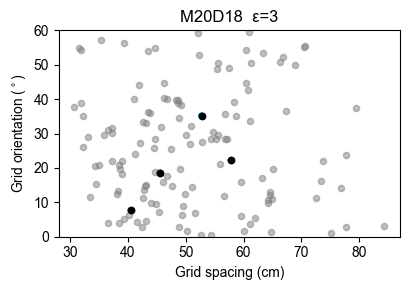

Processing M20 D19...
Processing M20 D20...


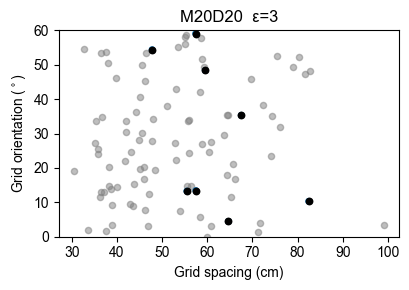

Processing M20 D21...
Processing M20 D22...
Processing M20 D23...


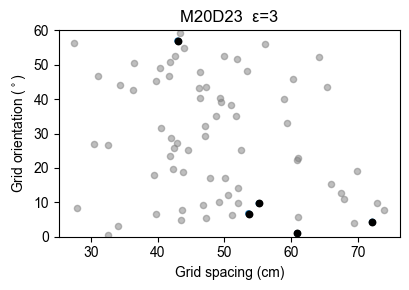

Processing M20 D24...


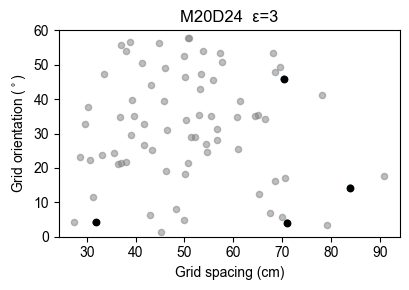

Processing M20 D25...


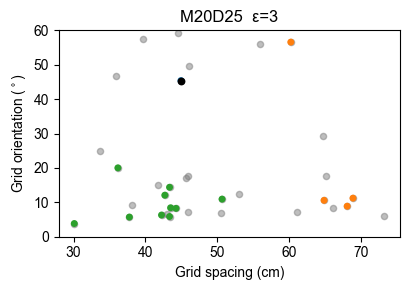

Processing M20 D26...


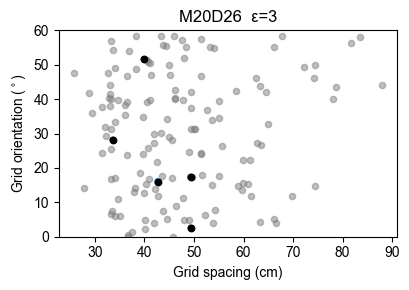

Processing M21 D15...


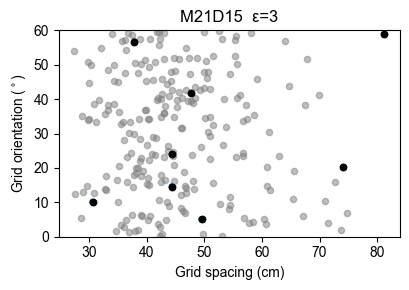

Processing M21 D16...


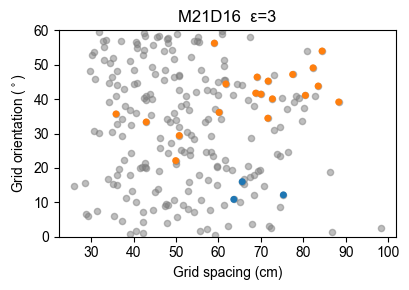

Processing M21 D17...


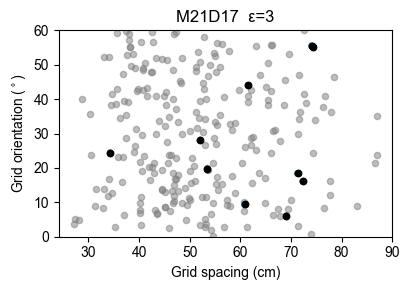

Processing M21 D18...


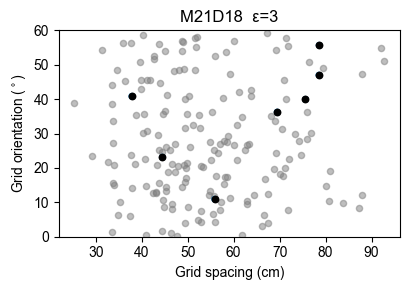

Processing M21 D19...


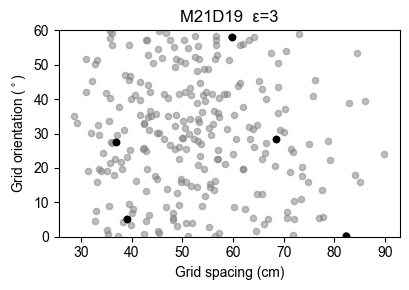

Processing M21 D20...


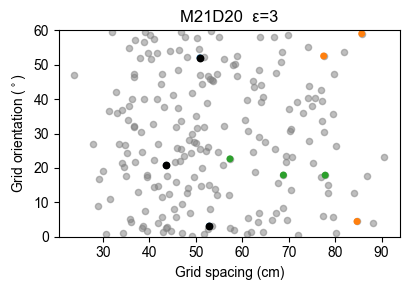

Processing M21 D21...


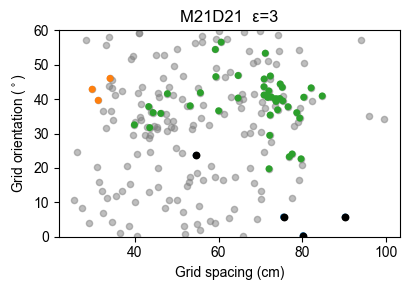

Processing M21 D22...


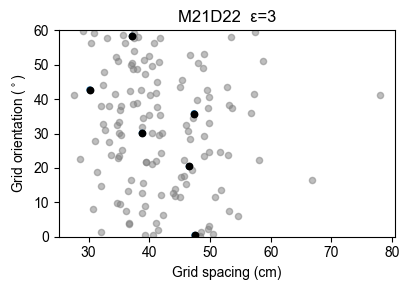

Processing M21 D23...


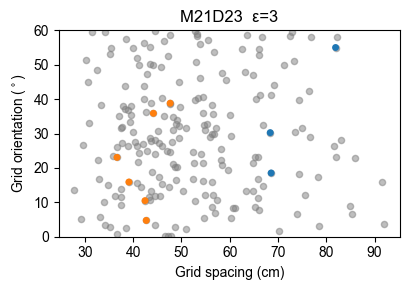

Processing M21 D24...


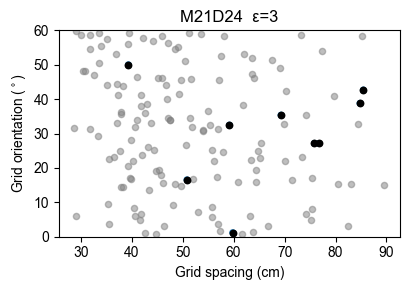

Processing M21 D25...


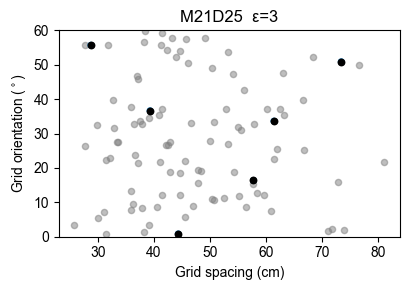

Processing M21 D26...


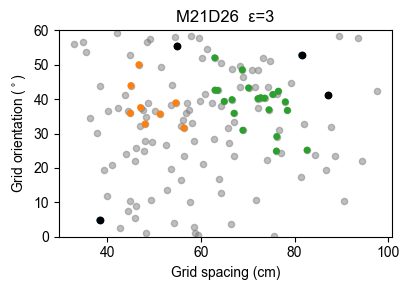

Processing M22 D33...
Processing M22 D34...
Processing M22 D35...
Processing M22 D36...
Processing M22 D37...
Processing M22 D38...


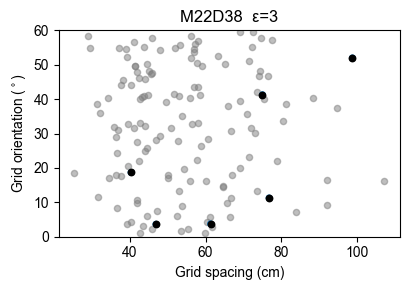

Processing M22 D39...
Processing M22 D40...
Processing M22 D41...
Processing M25 D16...
Processing M25 D17...
Processing M25 D18...


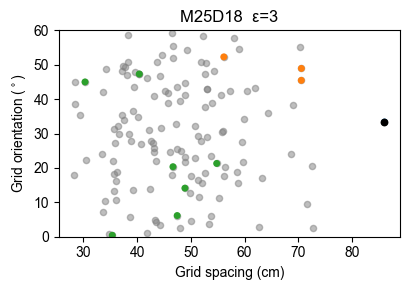

Processing M25 D19...


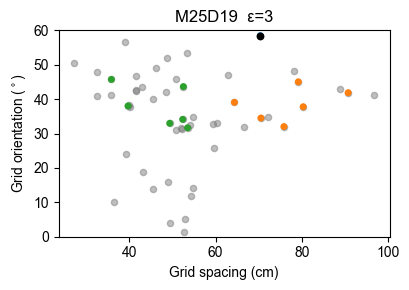

Processing M25 D20...


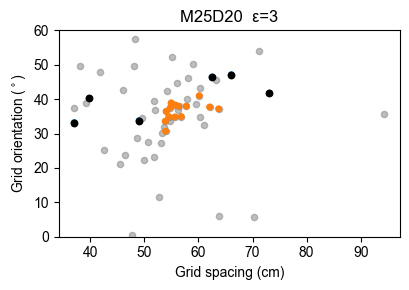

Processing M25 D21...


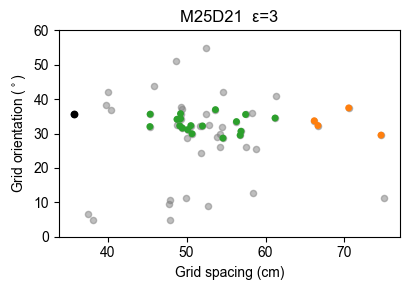

Processing M25 D22...


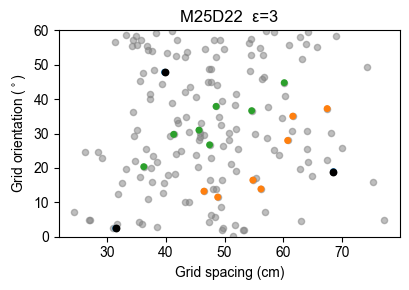

Processing M25 D23...


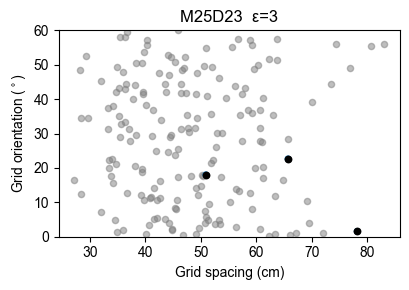

Processing M25 D24...


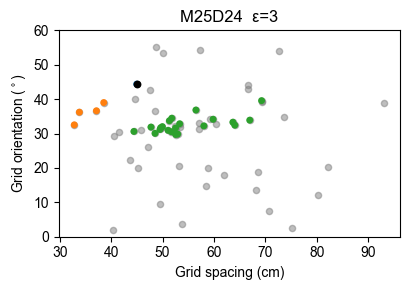

Processing M25 D25...


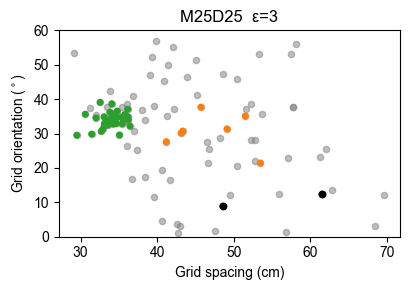

Processing M26 D11...


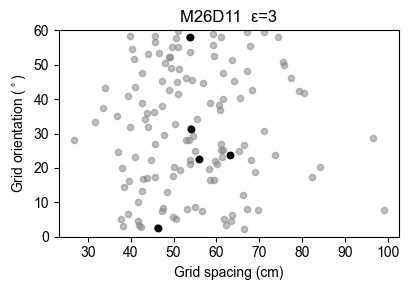

Processing M26 D12...


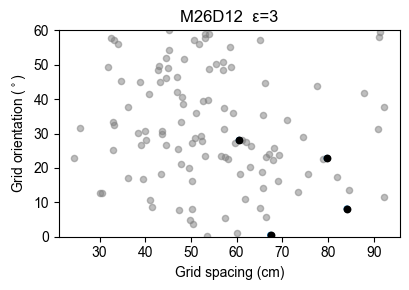

Processing M26 D13...


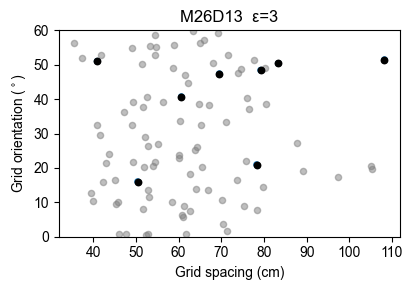

Processing M26 D14...
Processing M26 D15...


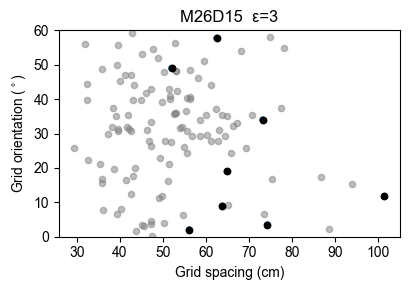

Processing M26 D16...
Processing M26 D17...
Processing M26 D18...


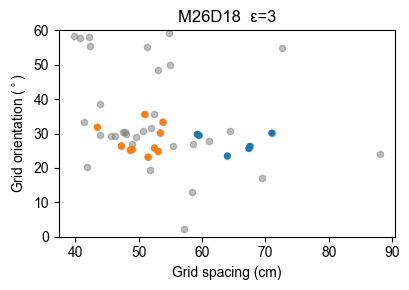

Processing M26 D19...


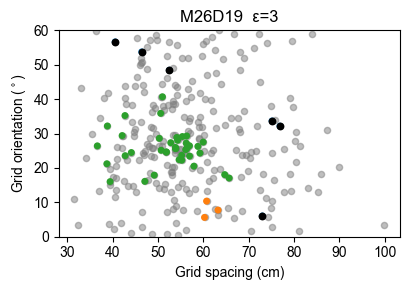

Processing M27 D16...
Processing M27 D17...
Processing M27 D18...


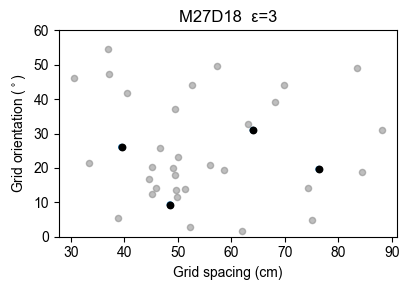

Processing M27 D19...
Processing M27 D20...


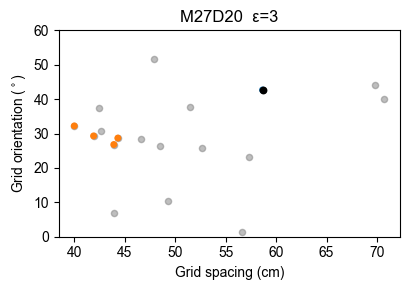

Processing M27 D21...
Processing M27 D22...
Processing M27 D23...


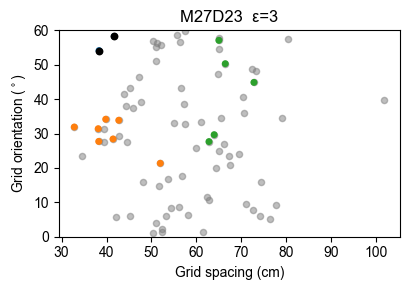

Processing M27 D24...


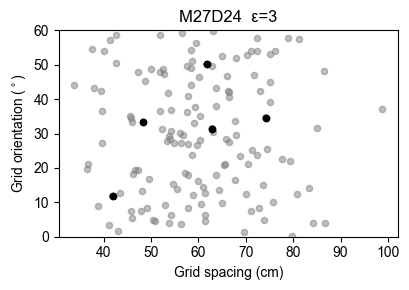

Processing M27 D26...


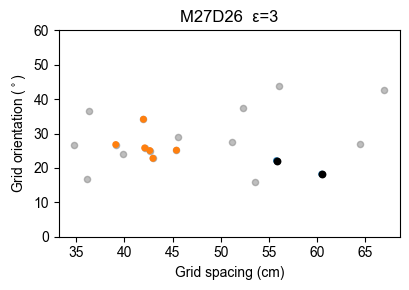

Processing M28 D16...


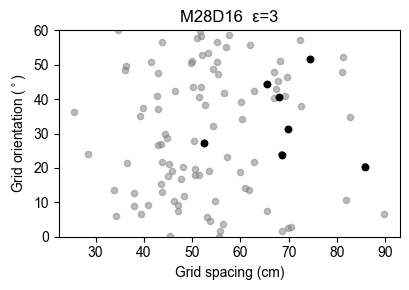

Processing M28 D17...


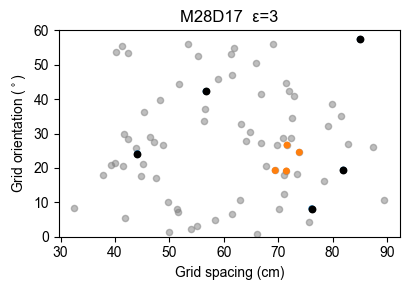

Processing M28 D18...
Processing M28 D19...


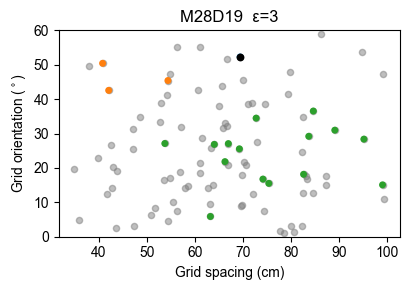

Processing M28 D20...


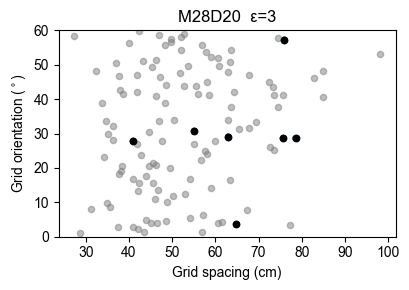

Processing M28 D21...


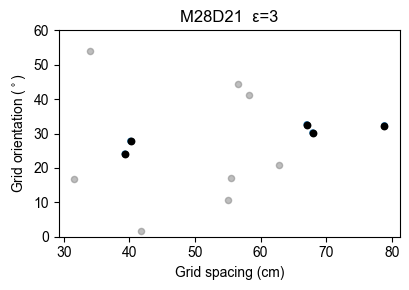

Processing M28 D22...
Processing M28 D23...


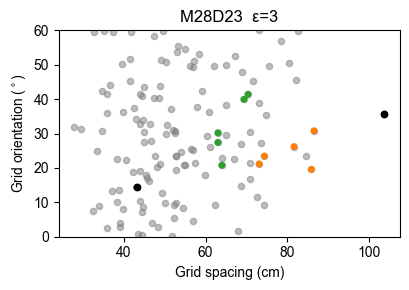

Processing M28 D25...


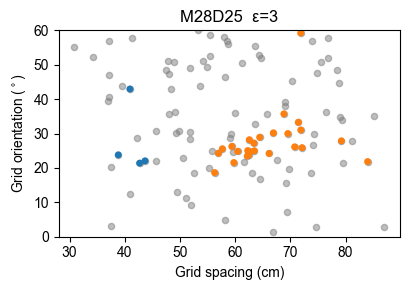

Processing M29 D16...


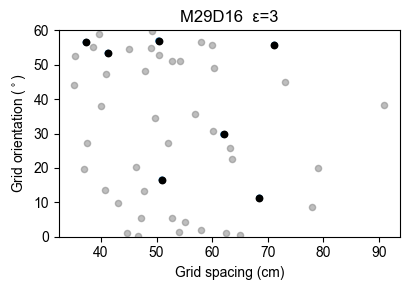

Processing M29 D17...


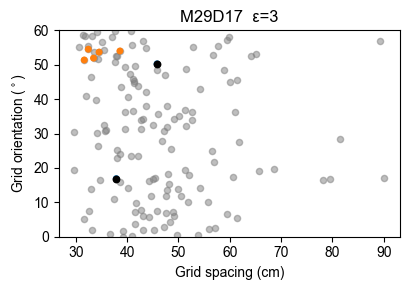

Processing M29 D18...
Processing M29 D19...


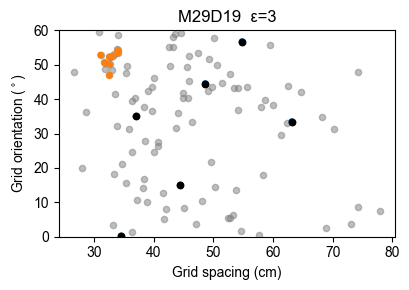

Processing M29 D20...


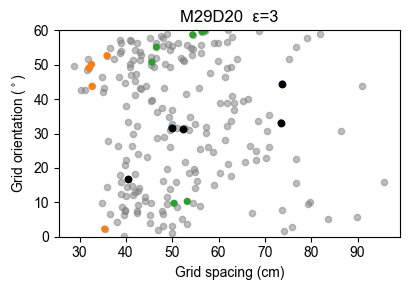

Processing M29 D21...


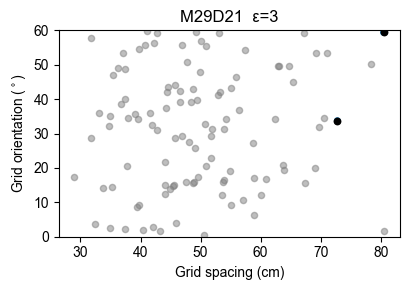

Processing M29 D22...
Processing M29 D23...


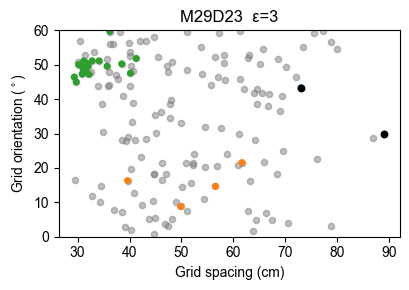

Processing M29 D25...


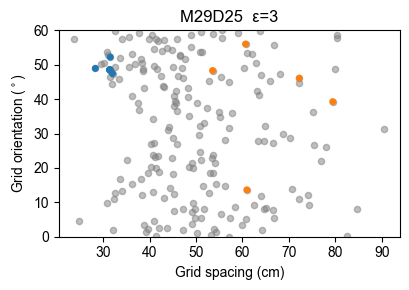

Done processing all sessions.
Total cells: 8915  |  GC: 706  |  NG: 6013  |  Other: 2196
GCs with a grid module assigned: 477


In [ ]:
import pandas as pd
from spatial_manifolds.detect_grids import (
    classify_cells_both_sessions,
    HDBSCAN_grid_modules,
    cell_classification_vr,
)

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

concatenated_results = []
for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing M{mouse} D{day:02}...")

        gcs, ngs, all_cells = classify_cells_both_sessions(
            mouse, day, percentile_threshold=95, source_path=None, verbose=False,
        )
        others = all_cells[~all_cells.index.isin(gcs.index) & ~all_cells.index.isin(ngs.index)]

        gcs    = gcs.copy()
        ngs    = ngs.copy()
        others = others.copy()

        gcs['cell_type']    = 'GC'
        ngs['cell_type']    = 'NG'
        others['cell_type'] = 'Other'

        # --- HDBSCAN grid modules ---
        gcs['grid_module']    = pd.NA
        ngs['grid_module']    = pd.NA
        others['grid_module'] = pd.NA

        try:
            g_m_ids, g_m_cluster_ids, _ = HDBSCAN_grid_modules(
                gcs, all_cells, mouse, day,
                min_cluster_size=3, cluster_selection_epsilon=3,
                curate_with_vr=False, curate_with_brain_region=True,
                figpath='', verbose=False,
            )
            for module_idx, cluster_ids in enumerate(g_m_cluster_ids):
                mask = gcs['cluster_id'].isin(cluster_ids)
                gcs.loc[mask, 'grid_module'] = module_idx
        except Exception as e:
            print(f"  WARNING: HDBSCAN failed for M{mouse} D{day}: {e}")

        # --- VR classification ---
        # ramp_cell:        True if cell has a significant outbound or homebound ramp
        # speed_modulated:  True if ramp_cell AND also speed-modulated
        # vr_outbound_sign / vr_homebound_sign: '+', '-', '/' for ramp cells; NaN otherwise
        combined = pd.concat([gcs, ngs, others])
        combined['ramp_cell']         = False
        combined['speed_modulated']   = False
        combined['vr_outbound_sign']  = pd.NA
        combined['vr_homebound_sign'] = pd.NA

        try:
            ramp_cells, ramp_and_speed_cells, non_spatial_cells = cell_classification_vr(
                mouse, day, percentile_threshold=99, source_path=None,
            )

            if len(ramp_cells) > 0:
                ramp_idx         = ramp_cells.set_index('cluster_id')
                speed_mod_lookup = ramp_idx['speed_modulated']
                out_sign_lookup  = ramp_idx['ramp_class'].str[0]
                home_sign_lookup = ramp_idx['ramp_class'].str[1]

                mask = combined['cluster_id'].isin(ramp_idx.index)
                combined.loc[mask, 'ramp_cell']         = True
                combined.loc[mask, 'speed_modulated']   = combined.loc[mask, 'cluster_id'].map(speed_mod_lookup)
                combined.loc[mask, 'vr_outbound_sign']  = combined.loc[mask, 'cluster_id'].map(out_sign_lookup)
                combined.loc[mask, 'vr_homebound_sign'] = combined.loc[mask, 'cluster_id'].map(home_sign_lookup)

        except Exception as e:
            print(f"  WARNING: VR classification failed for M{mouse} D{day}: {e}")

        concatenated_results.append(combined)

results = pd.concat(concatenated_results)

print("Done processing all sessions.")
print(
    f'Total cells: {len(results)}  |  '
    f'GC: {len(results[results.cell_type == "GC"])}  |  '
    f'NG: {len(results[results.cell_type == "NG"])}  |  '
    f'Other: {len(results[results.cell_type == "Other"])}'
)
print(f'GCs with a grid module assigned: {results["grid_module"].notna().sum()}')
print(f'\nramp_cell counts:\n{results["ramp_cell"].value_counts()}')
print(f'\nspeed_modulated counts:\n{results["speed_modulated"].value_counts()}')
print(f'\nvr_outbound_sign counts:\n{results["vr_outbound_sign"].value_counts()}')
print(f'vr_homebound_sign counts:\n{results["vr_homebound_sign"].value_counts()}')


In [4]:
results.to_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')